# Experiment No. 05
## Polynomial Regression, Overfitting, Ridge and Lasso Regularisation

**Aim:** Study polynomial regression and the effect of increasing model complexity on training and testing errors, identify overfitting, and apply Ridge (L2) and Lasso (L1) regularisation.

**Dataset:** `Housing.csv`  
**Predictor:** `area`  
**Target:** `price`

## 1. Import libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Load and inspect the dataset

In [2]:
file_name = "Housing.csv"
possible_paths = [Path(file_name), Path("Week 5") / file_name]
csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(f"Could not find {file_name}")

data = pd.read_csv(csv_path)
required_columns = {"area", "price"}
missing_columns = required_columns.difference(data.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print(f"Loaded {csv_path} with {data.shape[0]} rows and {data.shape[1]} columns.")
print("Missing values in selected columns:")
display(data[["area", "price"]].isna().sum().to_frame("Missing values"))
display(data.head())

Loaded Housing.csv with 545 rows and 13 columns.
Missing values in selected columns:


,Missing values
area,0
price,0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data[["area", "price"]].describe().round(2)

,area,price
count,545.0000,545.0000
mean,"5,150.5400","4,766,729.2500"
std,"2,170.1400","1,870,439.6200"
min,"1,650.0000","1,750,000.0000"
25%,"3,600.0000","3,430,000.0000"
50%,"4,600.0000","4,340,000.0000"
75%,"6,360.0000","5,740,000.0000"
max,"16,200.0000","13,300,000.0000"


## 3. Select variables and split the data

The lab requires one numerical predictor. `area` is used to predict `price`. An 80:20 train-test split with `random_state=42` makes the experiment reproducible. Price is divided by one million only while fitting models; predictions are converted back to the original price unit before calculating MSE.

In [4]:
X = data[["area"]]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
y_train_millions = y_train / 1_000_000

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")
print(f"Area-price correlation: {data['area'].corr(data['price']):.4f}")

Training rows: 436
Testing rows:  109
Area-price correlation: 0.5360


### Prediction before training

As polynomial degree increases, training MSE should decrease because the model becomes more flexible. Test MSE may first decrease and then increase. A much lower training MSE together with a rising test MSE indicates overfitting.

## 4. Helper functions

Each pipeline creates polynomial terms from the training data, standardizes those terms, and then fits the selected regression model. Standardization is essential for a fair Ridge/Lasso penalty and improves the numerical stability of high-degree features.

In [5]:
def make_polynomial_model(degree, estimator):
    return Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])


def evaluate_model(model):
    train_predictions = model.predict(X_train) * 1_000_000
    test_predictions = model.predict(X_test) * 1_000_000
    return {
        "Training MSE": mean_squared_error(y_train, train_predictions),
        "Testing MSE": mean_squared_error(y_test, test_predictions),
        "Training R2": r2_score(y_train, train_predictions),
        "Testing R2": r2_score(y_test, test_predictions),
    }

## 5. Polynomial regression for degrees 1, 3, 5, 7, and 10

In [6]:
degrees = [1, 3, 5, 7, 10]
polynomial_models = {}
degree_results = []

for degree in degrees:
    model = make_polynomial_model(degree, LinearRegression())
    model.fit(X_train, y_train_millions)
    polynomial_models[degree] = model
    degree_results.append({"Degree": degree, **evaluate_model(model)})

degree_results_df = pd.DataFrame(degree_results).set_index("Degree")
display(degree_results_df)

,Training MSE,Testing MSE,Training R2,Testing R2
Degree,,,,
1,"2,204,738,681,379.3413","3,675,286,604,768.1855",0.2850,0.2729
3,"2,063,400,239,338.4854","3,563,793,367,396.8369",0.3308,0.2949
5,"1,939,099,209,220.3328","3,717,573,668,645.7036",0.3711,0.2645
7,"1,920,333,820,246.5215","3,721,799,880,877.7158",0.3772,0.2637
10,"1,909,703,967,362.3721","3,813,251,778,147.1807",0.3806,0.2456


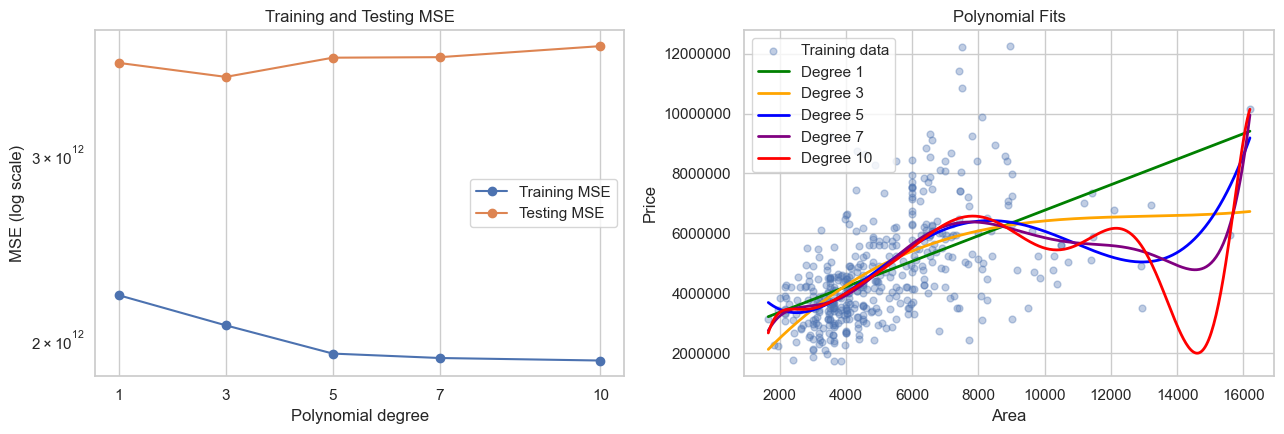

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(degrees, degree_results_df["Training MSE"], marker="o", label="Training MSE")
axes[0].plot(degrees, degree_results_df["Testing MSE"], marker="o", label="Testing MSE")
axes[0].set_yscale("log")
axes[0].set_xticks(degrees)
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("Training and Testing MSE")
axes[0].legend()

plot_area = pd.DataFrame({"area": np.linspace(X["area"].min(), X["area"].max(), 400)})
axes[1].scatter(X_train["area"], y_train, alpha=0.35, s=24, label="Training data")
for degree, color in zip(degrees, ["green", "orange", "blue", "purple", "red"]):
    curve = polynomial_models[degree].predict(plot_area) * 1_000_000
    axes[1].plot(plot_area["area"], curve, color=color, linewidth=2, label=f"Degree {degree}")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("Price")
axes[1].set_title("Polynomial Fits")
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
best_unregularised_degree = degree_results_df["Testing MSE"].idxmin()
degree_10_gap = (
    degree_results_df.loc[10, "Testing MSE"]
    - degree_results_df.loc[10, "Training MSE"]
)
print(f"Lowest unregularised test MSE: degree {best_unregularised_degree}")
print(f"Degree-10 generalisation gap: {degree_10_gap:,.2f}")
print("Degree 10 is treated as the overfit model because its training MSE falls while its test MSE rises relative to degree 3.")

Lowest unregularised test MSE: degree 3
Degree-10 generalisation gap: 1,903,547,810,784.81
Degree 10 is treated as the overfit model because its training MSE falls while its test MSE rises relative to degree 3.


## 6. Ridge and Lasso regularisation of the degree-10 model

Ridge adds an L2 penalty and shrinks all coefficients toward zero. Lasso adds an L1 penalty and can make some coefficients exactly zero. The same alpha grid is used for both methods.

In [9]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
regularisation_models = {}
regularisation_results = []

for method, estimator_factory in {
    "Ridge": lambda alpha: Ridge(alpha=alpha),
    "Lasso": lambda alpha: Lasso(alpha=alpha, max_iter=200_000, tol=1e-5),
}.items():
    for alpha in alphas:
        model = make_polynomial_model(10, estimator_factory(alpha))
        model.fit(X_train, y_train_millions)
        coefficients = model.named_steps["model"].coef_
        metrics = evaluate_model(model)
        regularisation_models[(method, alpha)] = model
        regularisation_results.append({
            "Method": method,
            "Alpha": alpha,
            **metrics,
            "Coefficient L2 Norm": np.linalg.norm(coefficients),
            "Zero Coefficients": int(np.sum(np.isclose(coefficients, 0, atol=1e-10))),
        })

regularisation_df = pd.DataFrame(regularisation_results)
display(regularisation_df)

,Method,Alpha,Training MSE,Testing MSE,Training R2,Testing R2,Coefficient L2 Norm,Zero Coefficients
0,Ridge,0.0010,"1,932,936,758,210.7764","3,714,157,936,467.1357",0.3731,0.2652,43.7425,0
1,Ridge,0.0100,"1,943,416,171,345.5081","3,724,532,382,197.8179",0.3697,0.2631,15.1425,0
2,Ridge,0.1000,"1,956,538,416,360.4592","3,726,766,217,224.4634",0.3655,0.2627,5.8122,0
3,Ridge,1.0000,"1,971,297,612,458.5061","3,716,714,131,091.0522",0.3607,0.2647,2.2729,0
4,Ridge,10.0000,"1,990,361,094,542.9543","3,675,903,806,206.8721",0.3545,0.2728,1.7271,0
5,Ridge,100.0000,"2,175,473,011,590.1282","3,784,662,431,102.8105",0.2945,0.2512,0.7903,0
6,Lasso,0.0010,"1,960,773,244,012.3701","3,733,982,895,738.8877",0.3641,0.2613,5.0480,5
7,Lasso,0.0100,"1,984,937,327,786.3730","3,661,607,743,858.7393",0.3562,0.2756,2.2223,7
8,Lasso,0.1000,"2,191,131,499,583.1089","3,739,045,138,812.4678",0.2894,0.2603,0.8811,8
9,Lasso,1.0000,"3,083,392,377,710.1357","5,145,176,852,226.2627",0.0000,-0.0179,0.0000,10


,Method,Alpha,Training MSE,Testing MSE,Training R2,Testing R2,Coefficient L2 Norm,Zero Coefficients
0,Lasso,0.0100,"1,984,937,327,786.3730","3,661,607,743,858.7393",0.3562,0.2756,2.2223,7
1,Ridge,10.0000,"1,990,361,094,542.9543","3,675,903,806,206.8721",0.3545,0.2728,1.7271,0


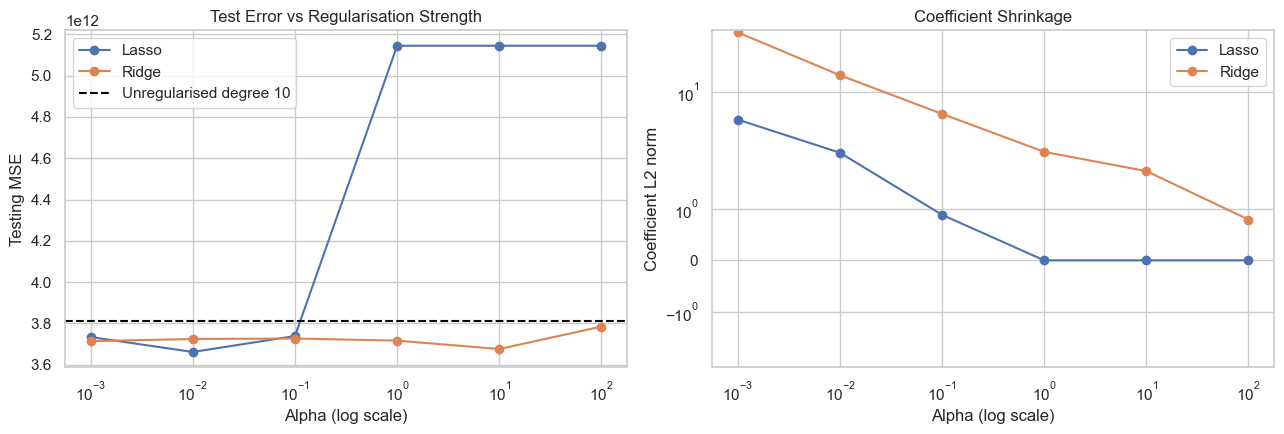

In [10]:
best_degree_10 = (
    regularisation_df.loc[regularisation_df.groupby("Method")["Testing MSE"].idxmin()]
    .sort_values("Testing MSE")
)
display(best_degree_10.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method, group in regularisation_df.groupby("Method"):
    axes[0].plot(group["Alpha"], group["Testing MSE"], marker="o", label=method)
    axes[1].plot(group["Alpha"], group["Coefficient L2 Norm"], marker="o", label=method)
axes[0].axhline(degree_results_df.loc[10, "Testing MSE"], color="black", linestyle="--", label="Unregularised degree 10")
for axis in axes:
    axis.set_xscale("log")
    axis.set_xlabel("Alpha (log scale)")
    axis.legend()
axes[0].set_ylabel("Testing MSE")
axes[0].set_title("Test Error vs Regularisation Strength")
axes[1].set_yscale("symlog")
axes[1].set_ylabel("Coefficient L2 norm")
axes[1].set_title("Coefficient Shrinkage")
plt.tight_layout()
plt.show()

## 7. Inspect coefficient shrinkage and Lasso sparsity

In [11]:
best_ridge_row = best_degree_10[best_degree_10["Method"] == "Ridge"].iloc[0]
best_lasso_row = best_degree_10[best_degree_10["Method"] == "Lasso"].iloc[0]
best_ridge_10 = regularisation_models[("Ridge", best_ridge_row["Alpha"])]
best_lasso_10 = regularisation_models[("Lasso", best_lasso_row["Alpha"])]

feature_names = polynomial_models[10].named_steps["polynomial"].get_feature_names_out(["area"])
coefficient_table = pd.DataFrame({
    "Term": feature_names,
    "Unregularised": polynomial_models[10].named_steps["model"].coef_,
    f"Ridge alpha={best_ridge_row['Alpha']:g}": best_ridge_10.named_steps["model"].coef_,
    f"Lasso alpha={best_lasso_row['Alpha']:g}": best_lasso_10.named_steps["model"].coef_,
})
display(coefficient_table)
print(f"Best Ridge coefficient norm: {np.linalg.norm(best_ridge_10.named_steps['model'].coef_):,.4f}")
print(f"Best Lasso zero coefficients: {np.sum(np.isclose(best_lasso_10.named_steps['model'].coef_, 0, atol=1e-10))} of 10")

,Term,Unregularised,Ridge alpha=10,Lasso alpha=0.01
0,area,309.7865,1.2516,1.6231
1,area^2,"-3,480.0094",0.4527,0.0000
2,area^3,"20,358.6439",-0.2707,-0.0000
3,area^4,"-78,078.2091",-0.5786,-1.3285
4,area^5,"205,597.7123",-0.5309,-0.0000
5,area^6,"-370,238.2357",-0.3147,-0.0000
6,area^7,"444,573.2418",-0.0620,-0.0000
7,area^8,"-338,446.7345",0.1679,0.0000
8,area^9,"147,161.3658",0.3585,0.0000
9,area^10,"-27,755.7443",0.5117,0.7343


Best Ridge coefficient norm: 1.7271
Best Lasso zero coefficients: 7 of 10


## 8. Try intermediate degrees with regularisation

Degrees 3, 5, and 7 are evaluated with Ridge and Lasso using the same alpha grid. This tests whether a simpler model generalises better than the regularised degree-10 model.

In [12]:
intermediate_models = {}
intermediate_results = []

for degree in [3, 5, 7]:
    for method, estimator_factory in {
        "Ridge": lambda alpha: Ridge(alpha=alpha),
        "Lasso": lambda alpha: Lasso(alpha=alpha, max_iter=200_000, tol=1e-5),
    }.items():
        for alpha in alphas:
            model = make_polynomial_model(degree, estimator_factory(alpha))
            model.fit(X_train, y_train_millions)
            coefficients = model.named_steps["model"].coef_
            intermediate_models[(degree, method, alpha)] = model
            intermediate_results.append({
                "Degree": degree,
                "Method": method,
                "Alpha": alpha,
                **evaluate_model(model),
                "Non-zero coefficients": int(np.sum(~np.isclose(coefficients, 0, atol=1e-10))),
            })

intermediate_df = pd.DataFrame(intermediate_results)
best_intermediate = (
    intermediate_df.loc[intermediate_df.groupby(["Degree", "Method"])["Testing MSE"].idxmin()]
    .sort_values("Testing MSE")
)
display(best_intermediate.reset_index(drop=True))

,Degree,Method,Alpha,Training MSE,Testing MSE,Training R2,Testing R2,Non-zero coefficients
0,3,Lasso,0.0010,"2,065,411,427,391.9421","3,562,224,275,170.4038",0.3301,0.2952,3
1,3,Ridge,0.1000,"2,063,972,987,534.4468","3,562,657,068,538.6646",0.3306,0.2952,3
2,5,Lasso,0.0100,"2,044,545,295,003.9128","3,578,810,529,894.1421",0.3369,0.2920,3
3,5,Ridge,1.0000,"2,012,938,957,513.5315","3,592,684,268,020.2280",0.3472,0.2892,5
4,7,Ridge,10.0000,"2,023,243,813,105.3882","3,620,993,698,067.5020",0.3438,0.2836,7
5,7,Lasso,0.0100,"1,996,762,029,436.9978","3,622,782,620,129.3877",0.3524,0.2833,3


## 9. Final model comparison and selection

In [13]:
candidate_rows = []
for degree, row in degree_results_df.iterrows():
    candidate_rows.append({
        "Degree": degree, "Method": "LinearRegression", "Alpha": 0.0,
        "Training MSE": row["Training MSE"], "Testing MSE": row["Testing MSE"],
        "Training R2": row["Training R2"], "Testing R2": row["Testing R2"],
        "Non-zero coefficients": degree,
    })
for _, row in best_degree_10.iterrows():
    candidate_rows.append({
        "Degree": 10, "Method": row["Method"], "Alpha": row["Alpha"],
        "Training MSE": row["Training MSE"], "Testing MSE": row["Testing MSE"],
        "Training R2": row["Training R2"], "Testing R2": row["Testing R2"],
        "Non-zero coefficients": 10 - int(row["Zero Coefficients"]),
    })
candidate_rows.extend(best_intermediate.to_dict(orient="records"))
candidate_df = (
    pd.DataFrame(candidate_rows)
    .sort_values(["Testing MSE", "Degree", "Non-zero coefficients"])
    .drop_duplicates(subset=["Degree", "Method", "Alpha"])
)
display(candidate_df.reset_index(drop=True))

final_model = candidate_df.iloc[0]
print(
    f"Selected model: degree {int(final_model['Degree'])} {final_model['Method']} "
    f"(alpha={final_model['Alpha']:g}) with test MSE {final_model['Testing MSE']:,.2f} "
    f"and test R2 {final_model['Testing R2']:.4f}."
)

,Degree,Method,Alpha,Training MSE,Testing MSE,Training R2,Testing R2,Non-zero coefficients
0,3,Lasso,0.0010,"2,065,411,427,391.9421","3,562,224,275,170.4038",0.3301,0.2952,3
1,3,Ridge,0.1000,"2,063,972,987,534.4468","3,562,657,068,538.6646",0.3306,0.2952,3
2,3,LinearRegression,0.0000,"2,063,400,239,338.4854","3,563,793,367,396.8369",0.3308,0.2949,3
3,5,Lasso,0.0100,"2,044,545,295,003.9128","3,578,810,529,894.1421",0.3369,0.2920,3
4,5,Ridge,1.0000,"2,012,938,957,513.5315","3,592,684,268,020.2280",0.3472,0.2892,5
5,7,Ridge,10.0000,"2,023,243,813,105.3882","3,620,993,698,067.5020",0.3438,0.2836,7
6,7,Lasso,0.0100,"1,996,762,029,436.9978","3,622,782,620,129.3877",0.3524,0.2833,3
7,10,Lasso,0.0100,"1,984,937,327,786.3730","3,661,607,743,858.7393",0.3562,0.2756,3
8,1,LinearRegression,0.0000,"2,204,738,681,379.3413","3,675,286,604,768.1855",0.2850,0.2729,1
9,10,Ridge,10.0000,"1,990,361,094,542.9543","3,675,903,806,206.8721",0.3545,0.2728,10


Selected model: degree 3 Lasso (alpha=0.001) with test MSE 3,562,224,275,170.40 and test R2 0.2952.


## 10. Automated checks

In [14]:
assert {"area", "price"}.issubset(data.columns)
assert data[["area", "price"]].isna().sum().sum() == 0
assert X_train.index.intersection(X_test.index).empty
assert list(degree_results_df.index) == [1, 3, 5, 7, 10]
assert degree_results_df.loc[10, "Training MSE"] < degree_results_df.loc[3, "Training MSE"]
assert degree_results_df.loc[10, "Testing MSE"] > degree_results_df.loc[3, "Testing MSE"]
assert best_lasso_row["Zero Coefficients"] > 0
assert np.isfinite(candidate_df.select_dtypes(include=np.number).to_numpy()).all()
print("All checks passed.")

All checks passed.


## 11. Conclusion

Increasing polynomial degree reduced training error at every tested degree, but test error improved only from degree 1 to degree 3. Degrees 5, 7, and 10 had progressively lower training errors but worse test performance than degree 3, showing that overfitting begins after degree 3. Ridge reduced the magnitude of the degree-10 coefficients, while Lasso both shrank coefficients and set several of them exactly to zero. The final model was selected primarily by the lowest test MSE, with lower degree and fewer active coefficients used as simplicity tie-breakers.

## Viva Questions - Short Answers

1. **What is polynomial regression?** It is linear regression applied to polynomial transformations such as $x$, $x^2$, and $x^3$, allowing a curved relationship between predictor and target.
2. **What happens when polynomial degree is increased?** Model flexibility increases, training error usually falls, and variance and overfitting risk rise.
3. **What is the difference between Ridge and Lasso?** Ridge uses an L2 penalty and usually shrinks all coefficients; Lasso uses an L1 penalty and can set coefficients exactly to zero.
4. **What is the role of alpha?** Alpha controls regularisation strength; larger alpha gives stronger coefficient shrinkage.
5. **Why is degree 10 more likely to overfit?** It has many flexible polynomial terms that can model training noise and extreme bends.
6. **What is coefficient shrinkage?** It is the reduction of coefficient magnitudes caused by a regularisation penalty.
7. **What is sparsity in Lasso regression?** Sparsity means that some fitted coefficients are exactly zero, so the corresponding terms are excluded.
8. **Why compare train and test MSE?** Their difference reveals whether the model generalises or merely fits the training data.
9. **Why prefer an intermediate degree over degree 10?** It can capture useful curvature with lower variance, better test performance, and easier interpretation.
10. **What is the bias-variance trade-off?** Simple models tend to have higher bias and lower variance; complex models tend to have lower bias and higher variance. A good model balances both.